****PART A: Data preparation****

In [3]:
import sys
sys.path.append('../')

from src.dataload import load_data
from src.preprocessing import preprocess_data
from src.feature_engineering import create_features
from src.aggregation import create_daily_metrics
from src.merge import merge_datasets

import pandas as pd

In [4]:
sentiment, trades = load_data(
    "../data/raw/fear_greed_index.csv",
    "../data/raw/historical_data.csv"
)

In [5]:
print("Sentiment shape: ",sentiment.shape)
print("Trades shape: ", trades.shape)

print("\nMissing Values: ", sentiment.isnull().sum())
print("\nMissing Values: ",trades.isnull().sum())

print("\nDuplicates: ",sentiment.duplicated().sum())
print("Duplicates: ",trades.duplicated().sum())

Sentiment shape:  (2644, 4)
Trades shape:  (211224, 16)

Missing Values:  timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values:  Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:  0
Duplicates:  0


In [6]:
sentiment,trades = preprocess_data(sentiment,trades)

In [7]:
trades=create_features(trades)

In [8]:
daily_metrics = create_daily_metrics(trades)
daily_metrics.head()

,date,daily_pnl,win_rate,avg_trade_size,num_trades,long_ratio
0,2023-05-01,0.000000,0.000000,159.000000,3,1.000000
1,2023-12-05,0.000000,0.000000,5556.203333,9,0.777778
2,2023-12-14,-205.434737,0.363636,10291.213636,11,0.454545
3,2023-12-15,-24.632034,0.000000,5304.975000,2,1.000000
4,2023-12-16,0.000000,0.000000,5116.256667,3,1.000000


In [9]:
final_df = merge_datasets(daily_metrics, sentiment)
final_df.head()

,date,daily_pnl,win_rate,avg_trade_size,num_trades,long_ratio,classification
0,2023-05-01,0.000000,0.000000,159.000000,3,1.000000,Greed
1,2023-12-05,0.000000,0.000000,5556.203333,9,0.777778,Extreme Greed
2,2023-12-14,-205.434737,0.363636,10291.213636,11,0.454545,Greed
3,2023-12-15,-24.632034,0.000000,5304.975000,2,1.000000,Greed
4,2023-12-16,0.000000,0.000000,5116.256667,3,1.000000,Greed


In [10]:
final_df.to_csv(
    "C:/Users/Ritika Sundar/OneDrive/Desktop/SNU/SEMESTER 6/primetrade/data/preprocessed/final_dataset.csv",
    index=False
)

In [11]:
def simplify_sentiment(x):
    if 'Fear' in x:
        return 'Fear'
    else:
        return 'Greed'
final_df['sentiment']=final_df['classification'].apply(simplify_sentiment)

****PART B: Data Analysis****

1. Performance vs Sentiment

In [12]:
perf_summary=final_df.groupby('sentiment').agg({
    'daily_pnl':['mean','std'],
    'win_rate':'mean'
}).reset_index()
perf_summary.columns=['sentiment','avg_pnl','pnl_volatality','avg_win_rate']
perf_summary

,sentiment,avg_pnl,pnl_volatality,avg_win_rate
0,Fear,39012.054192,96894.941505,0.328876
1,Greed,16465.832244,62457.588945,0.375315


<function matplotlib.pyplot.show(close=None, block=None)>

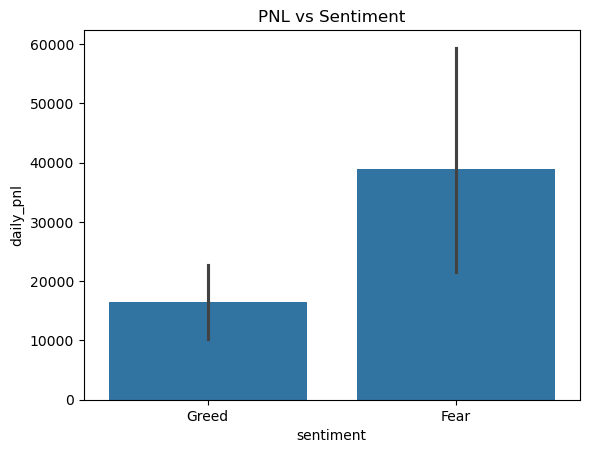

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
#PNL plot
sns.barplot(data=final_df,x='sentiment',y='daily_pnl')
plt.title("PNL vs Sentiment")
plt.show

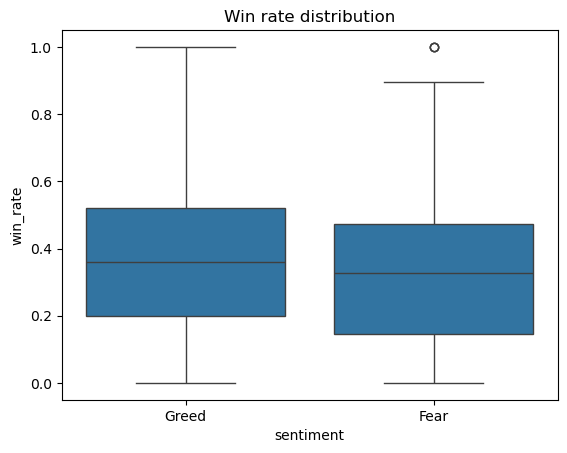

In [15]:
#Win Rate
sns.boxplot(data=final_df,x='sentiment',y='win_rate')
plt.title("Win rate distribution")
plt.show()

Observation:
- Greed days show lower average PNL compared to Fear
- Win rate is greater during greed periods but inconsistent (observed from the whisker spread)

2. Behaviour vs Sentiment

In [16]:
behaviour_summary=final_df.groupby('sentiment').agg({
    'num_trades':'mean',
    'avg_trade_size':'mean',
    'long_ratio':'mean'    
}).reset_index()

behaviour_summary

,sentiment,num_trades,avg_trade_size,long_ratio
0,Fear,792.733333,6199.962861,0.509901
1,Greed,342.195187,6102.316043,0.483436


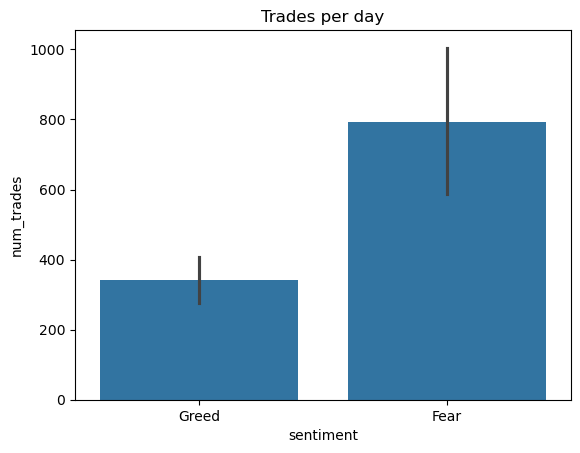

In [17]:
#trade frequency
sns.barplot(data=final_df,x='sentiment',y='num_trades')
plt.title("Trades per day")
plt.show()

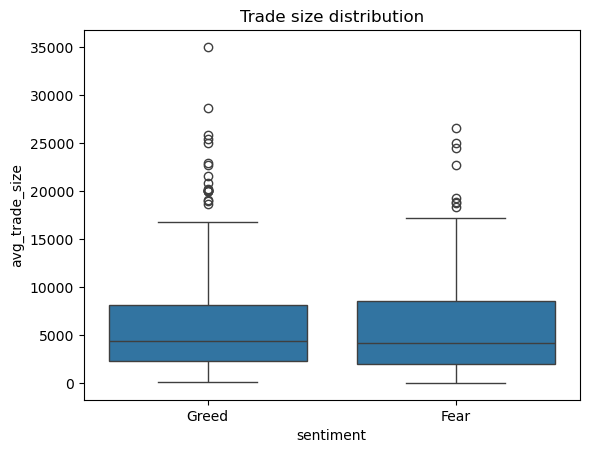

In [18]:
#trade size
sns.boxplot(data=final_df, x='sentiment', y='avg_trade_size')
plt.title("Trade size distribution")
plt.show()

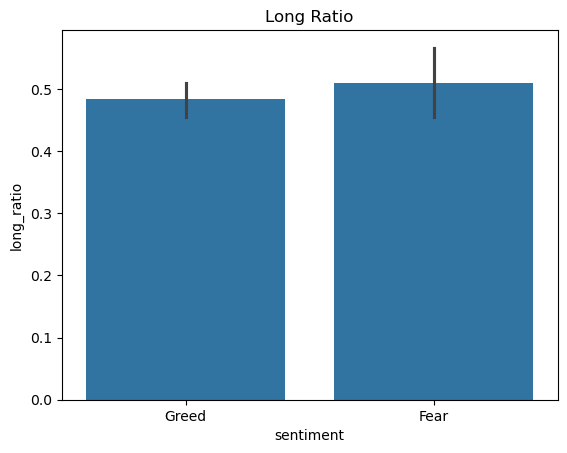

In [19]:
#long bias
sns.barplot(data=final_df,x='sentiment',y='long_ratio')
plt.title("Long Ratio")
plt.show()

Observation:
- Number of trades per day increases with fear
- The distribution of trades is the same. But sometimes, traders get overconfident with Greed and make higher trades (the outliers are more for Greed)
- Markets would work better in Fear as the long ratio is higher when observed in the plot

3. Segmentation

i) High vs Low activity traders

In [ ]:
median_trades=final_df['num_trades'].median()
final_df['activity_group']=final_df['num_trades'].apply(
    lambda x: 'High Activity' if x>median_trades else 'Low Activity'
)

ii) Large vs Small Trade size

In [21]:
median_size=final_df['avg_trade_size'].median()
final_df['size_group']=final_df['avg_trade_size'].apply(
    lambda x: 'Large Trades' if x>median_size else 'Small Trades'
)

4. Segment Analysis

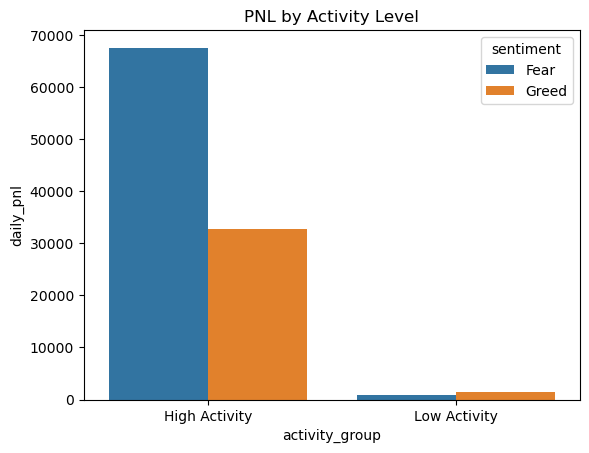

In [26]:
activity_perf=final_df.groupby(
    ['activity_group', 'sentiment']
)['daily_pnl'].mean().reset_index()

sns.barplot(data=activity_perf, x='activity_group', y='daily_pnl', hue='sentiment')
plt.title("PNL by Activity Level")
plt.show()

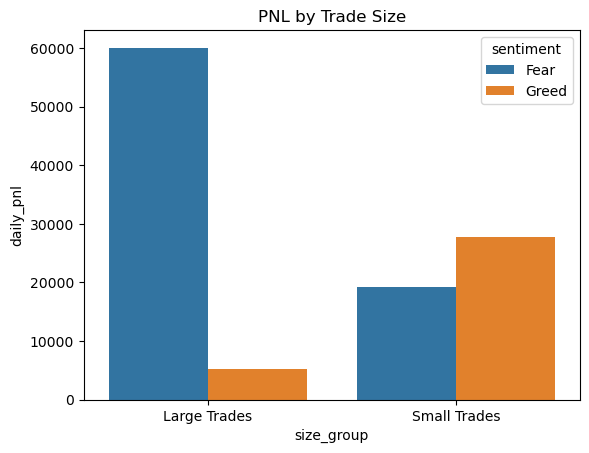

In [27]:
size_perf=final_df.groupby(
    ['size_group', 'sentiment']
)['daily_pnl'].mean().reset_index()

sns.barplot(data=size_perf, x='size_group', y='daily_pnl', hue='sentiment')
plt.title("PNL by Trade Size")
plt.show()

****PART C: Actionable Output****

**OUTPUT 1:**

- Average PNL is higher during fear periods
- Traders are found making more trades per day in this period as well

STRATEGY:
- Increase the trading frequency during this period and actively make trades

**OUTPUT 2:**

- Win rate remains almost the same across fear and greed
- PNL varies drastically

STRATEGY:
- During fear periods, do not optimize the win rate
- Focus on the higher risk-reward ratio